In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from math import nan
import yaml

sys.path.append("/glade/u/home/islas/python/CESM2_with_CMIP7_aer/utils/")
from reading_utils import *
from convert_units import *

In [3]:
# import molecular weights
from molecular_weights import *

In [4]:
# species to plot
species_to_plot = ['SO2','so4_a1','bc_a4','pom_a4','SOAG']
emiss_type_to_plot = ['sfc','sfc','sfc','sfc','sfc']
forcing_type_to_plot = ['bmb','bmb','bmb','bmb','bmb']

In [5]:
cmip6_pi_plot = []
cmip7_pi_plot = []
cmip6_hist_plot = []
cmip7_hist_plot = []
unsmoothed_plot = []
smoothed_plot = []

for iplot in np.arange(0,len(species_to_plot),1):
    species = species_to_plot[iplot]
    emiss_type = emiss_type_to_plot[iplot]
    forcing_type = forcing_type_to_plot[iplot]

    # Read in the modified emissions file
    outpath="/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/"+forcing_type+"/"+emiss_type+"/CMIP7/"
    fout = outpath+"/"+species+"_"+forcing_type+"_"+emiss_type+"_cmip7_for_cesm2_negspread.nc"
    unsmoothed = xr.open_dataset(fout)
    unsmoothed = unsmoothed.emiss

    outpath="/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/"+forcing_type+"/"+emiss_type+"/CMIP7/"
    fout = outpath+"/"+species+"_smoothed_"+forcing_type+"_"+emiss_type+"_cmip7_for_cesm2_negspread.nc"
    smoothed = xr.open_dataset(fout)
    smoothed = smoothed.emiss

    # Read in the original emissions files
    cmip6_pi = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip6','piControl')
    cmip7_pi = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip7','piControl', dstgrid = 'f09')
    cmip6_hist = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip6','hist')
    cmip7_hist = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip7','hist', dstgrid='f09')

    # Sum over emissions type
    cmip6_pi = cmip6_pi.sum('emiss_type')
    cmip7_pi = cmip7_pi.sum('emiss_type')
    cmip6_hist = cmip6_hist.sum('emiss_type')
    cmip7_hist = cmip7_hist.sum('emiss_type')

    cmip6_hist = cmip6_hist.sel(time=slice("1850-01-01","2025-12-31"))
    cmip7_hist = cmip7_hist.sel(time=slice("1850-01-01","2025-12-31"))
    unsmoothed = unsmoothed.sel(time=slice("1850-01-01","2025-12-31"))
    smoothed = smoothed.sel(time=slice("1850-01-01","2025-12-31"))

    # Convert to Tg
    cmip6_pi_tg = convert_molecules_to_tg_specifywgt(cmip6_pi, mol_weights[species])
    cmip7_pi_tg = convert_molecules_to_tg_specifywgt(cmip7_pi, mol_weights[species])
    cmip6_hist_tg = convert_molecules_to_tg_specifywgt(cmip6_hist, mol_weights[species])
    cmip7_hist_tg = convert_molecules_to_tg_specifywgt(cmip7_hist, mol_weights[species])
    unsmoothed_tg = convert_molecules_to_tg_specifywgt(unsmoothed, mol_weights[species])
    smoothed_tg = convert_molecules_to_tg_specifywgt(smoothed, mol_weights[species])

    # Calculate annual mean
    cmip6_pi_tg_am = cal.calcannualmean(cmip6_pi_tg)
    cmip7_pi_tg_am = cal.calcannualmean(cmip7_pi_tg)
    cmip6_hist_tg_am = cal.calcannualmean(cmip6_hist_tg)
    cmip7_hist_tg_am = cal.calcannualmean(cmip7_hist_tg)
    unsmoothed_tg_am = cal.calcannualmean(unsmoothed_tg)
    smoothed_tg_am = cal.calcannualmean(smoothed_tg)

    cmip6_pi_tg_am = cmip6_pi_tg_am.load()
    cmip7_pi_tg_am = cmip7_pi_tg_am.load()
    cmip6_hist_tg_am = cmip6_hist_tg_am.load()
    cmip7_hist_tg_am = cmip7_hist_tg_am.load()
    unsmoothed_tg_am = unsmoothed_tg_am.load()
    smoothed_tg_am = smoothed_tg_am.load()

    cmip6_pi_plot.append(cmip6_pi_tg_am)
    cmip7_pi_plot.append(cmip7_pi_tg_am)
    cmip6_hist_plot.append(cmip6_hist_tg_am)
    cmip7_hist_plot.append(cmip7_hist_tg_am)
    unsmoothed_plot.append(unsmoothed_tg_am)
    smoothed_plot.append(smoothed_tg_am)

/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370-BB_smoothed/emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_smoothed_SO2_bb_surface_mol_175001-210101_0.9x1.25_c20201016.nc
emiss_bb
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/SO2_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-1_gn_175001-202312_c20251102.nc
emiss
/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370-BB_smoothed/emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_smoothed_SO2_bb_surface_mol_175001-210101_0.9x1.25_c20201016.nc
emiss_bb
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/SO2_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-1_gn_175001-202312_c20251102.nc
emiss
/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370-BB_smoothed/emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_smoothed_so4_a1_bb_surface_mol_175001-210101_0.9x1.25_c20201016.nc
emiss_bb
/glade/campaign/cgd/cas/islas/python_sav

In [6]:
def plot_the_plot(fig, cmip6_pi, cmip6_hist, cmip7_pi, cmip7_hist, unsmoothed, smoothed, titlestr, x1, x2, y1, y2):
    ax = fig.add_axes([x1, y1, (x2-x1), (y2-y1)])
    ax.set_title(titlestr, fontsize=16)
    ax.set_ylabel('Emissions (Tg/s)', fontsize=14)
    ax.plot(cmip6_hist.year, cmip6_hist, color='royalblue', label='CMIP6')
    #ax.plot([1850,2025],[cmip6_pi, cmip6_pi], color='royalblue', linestyle='dashed', label='CMIP6 piControl')
    ax.plot(cmip7_hist.year, cmip7_hist, color='red', label='CMIP7')
    #ax.plot([1850,2025],[cmip7_pi, cmip7_pi], color='red', linestyle='dotted', label='CMIP7 piControl')
    ax.plot(unsmoothed.year, unsmoothed, color='orange', linestyle='dashed', linewidth=2, label='CMIP7 adjusted')
    ax.plot(smoothed.year, smoothed, color='black', linestyle='solid', linewidth=2, label='CMIP7 smoothed')
    ax.legend()
    return ax

In [9]:
x1=[0.0,0.31,0.62,
    0.0,0.31,0.62,
    0.0,0.31,0.62,
    0.0,0.31,0.62]
x2=[0.26,0.57,0.88,
    0.26,0.57,
    0.26,0.57,
    0.26,0.57]
y1=[0.8,0.8,
    0.59,0.59,
    0.38,0.38,
    0.17,0.17]
y2=[0.97,0.97,
    0.76,0.76,
    0.55,0.55,
    0.34,0.34]

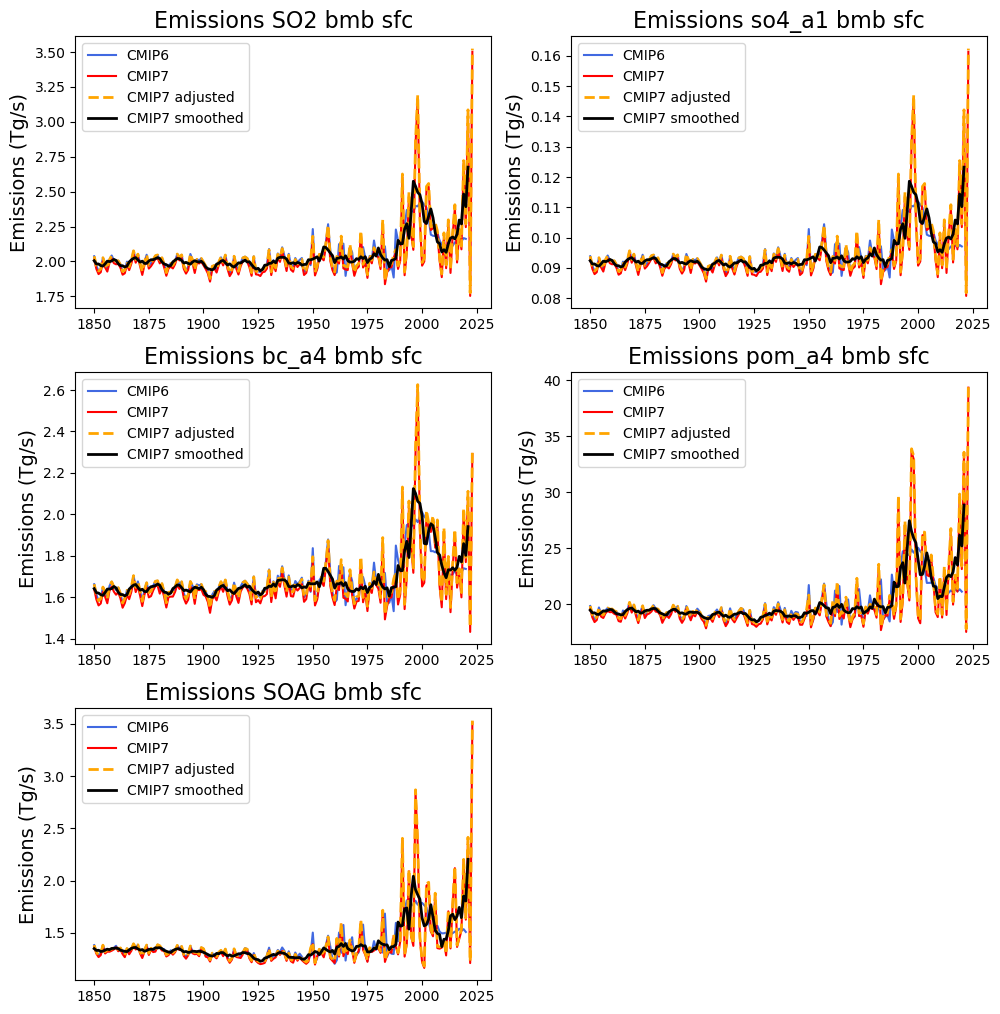

In [10]:
fig = plt.figure(figsize=(16,16))

for iplot in np.arange(0,len(cmip6_pi_plot),1):
    ax = plot_the_plot(fig, cmip6_pi_plot[iplot], cmip6_hist_plot[iplot], cmip7_pi_plot[iplot], cmip7_hist_plot[iplot], unsmoothed_plot[iplot], smoothed_plot[iplot],
                      'Emissions '+species_to_plot[iplot]+' '+forcing_type_to_plot[iplot]+' '+emiss_type_to_plot[iplot],
                      x1[iplot],x2[iplot],y1[iplot],y2[iplot])